In [1]:
import pandas as pd 
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import numpy as np

In [2]:
# read in data
master_table = pd.read_csv('c:/Users/claro/OneDrive - Cornell University/Quantitative Modeling/Rotten Tomatoes/data/master_table.csv')
reviews = pd.read_csv('c:/Users/claro/OneDrive - Cornell University/Quantitative Modeling/Rotten Tomatoes/data/reviews.csv')
movies = pd.read_csv('c:/Users/claro/OneDrive - Cornell University/Quantitative Modeling/Rotten Tomatoes/data/movies.csv')

print(movies.head())

                     id                title  audienceScore  tomatoMeter  \
0    space-zombie-bingo  Space Zombie Bingo!           50.0          NaN   
1       the_green_grass      The Green Grass            NaN          NaN   
2             love_lies           Love, Lies           43.0          NaN   
3  the_sore_losers_1997          Sore Losers           60.0          NaN   
4  dinosaur_island_2002      Dinosaur Island           70.0          NaN   

  rating                          genre  runtimeMinutes  \
0    NaN         Comedy, Horror, Sci-fi            75.0   
1    NaN                          Drama           114.0   
2    NaN                          Drama           120.0   
3    NaN     Action, Mystery & thriller            90.0   
4    NaN  Fantasy, Adventure, Animation            80.0   

                        director                                  writer  
0                  George Ormrod              George Ormrod,John Sabotta  
1                Tiffany Edwards      

### **Idea 1: Can we utilize public audience score to predict tomato score?**

In [3]:
# removing rows that have no tomatoMeter score
movies_cleaned = movies.dropna(subset=['tomatoMeter','audienceScore'])

# removing rows that have 0% or 100% scores for either tomatoMeter or audience score (because this generally implies a low qty of ratings)
movies_cleaned = movies_cleaned[
    (movies_cleaned['tomatoMeter'] != 0) & 
    (movies_cleaned['tomatoMeter'] != 100) & 
    (movies_cleaned['audienceScore'] != 0) & 
    (movies_cleaned['audienceScore'] != 100)
]

model = smf.ols('tomatoMeter ~ audienceScore + runtimeMinutes', data = movies_cleaned)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:            tomatoMeter   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     6845.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:19:31   Log-Likelihood:            -1.1692e+05
No. Observations:               26249   AIC:                         2.338e+05
Df Residuals:                   26246   BIC:                         2.339e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.9528      0.717     34.

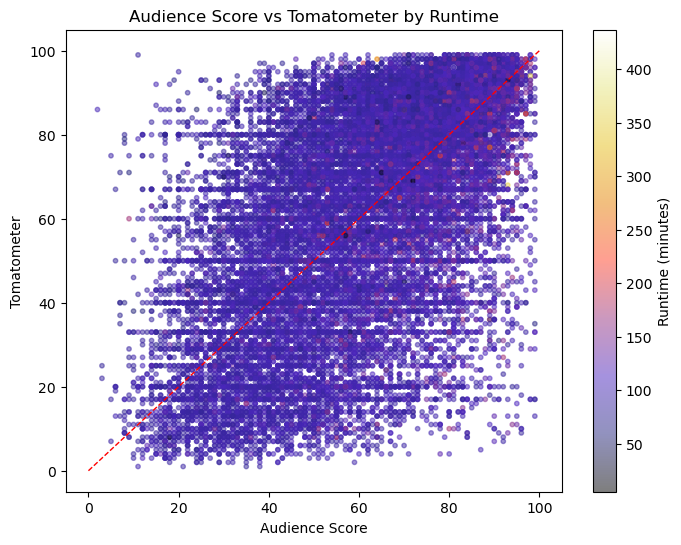

In [4]:
# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(movies_cleaned['audienceScore'],
                     movies_cleaned['tomatoMeter'],
                     c=movies_cleaned['runtimeMinutes'],  # gradient based on this
                     cmap='CMRmap',                          # color scheme
                     alpha=0.5,
                     s=10)

plt.colorbar(scatter, label='Runtime (minutes)')  # adds the color scale bar

# Add y = x line. If point is below, audience score > tomatometer score
lims = [0, 100]  # set based on your data range
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

plt.xlabel('Audience Score')
plt.ylabel('Tomatometer')
plt.title('Audience Score vs Tomatometer by Runtime')
plt.show()


In [5]:
# number of movies where tomatoMeter score > audienceScore
critics_higher = movies_cleaned[movies_cleaned['tomatoMeter'] > movies_cleaned['audienceScore']]
print(f"Movies where critics scored higher: {len(critics_higher)} ({len(critics_higher)*100 //len(movies_cleaned)}%)")

# and the opposite
audience_higher = movies_cleaned[movies_cleaned['audienceScore'] > movies_cleaned['tomatoMeter']]
print(f"Movies where audience scored higher: {len(audience_higher)} ({len(audience_higher)*100 //len(movies_cleaned)}%)")

# and equal
equal = movies_cleaned[movies_cleaned['audienceScore'] == movies_cleaned['tomatoMeter']]
print(f"Movies where scores are equal: {len(equal)} ({len(equal)*100 //len(movies_cleaned)}%)")

Movies where critics scored higher: 14786 (55%)
Movies where audience scored higher: 11411 (42%)
Movies where scores are equal: 562 (2%)


#### **Findings**: 
Contrary to what one would expect, there is only a *slight* correlation between audience score and tomatometer score. We will need to investigate futher in finding the reason why discrepensies between tomatometer and audience scores exist. It is also confusing that visually, the proportion of movies where audience score > tomatometer score is roughtly a half. 

**Next Step**: Instead of audience score, can we look at public sentiments? Webscrape public forums for audience sentiments.


### **Idea 2: What are the most consistent critics? Can we predict tomato score with a linear combination of critic ratings weighted by consistency?**

In [6]:
# clean master table (contains all ratings + movies' tomato scores)
master_table_cleaned = master_table.dropna(subset = ['tomatoMeter', 'reviewId','originalScore'])
master_table_cleaned = master_table_cleaned.drop_duplicates(subset=['reviewId'])

# getting counts of all ratings by critic name and review site
agg_by_critic = master_table_cleaned.groupby(['criticName','isTopCritic'])['reviewId'].count()
agg_by_critic = agg_by_critic.sort_values(ascending=False)
agg_by_critic.head(20)


criticName           isTopCritic
Emanuel Levy         False          10052
Dennis Schwartz      False           9207
Roger Ebert          True            6913
Brian Orndorf        False           6651
Frank Swietek        False           6574
David Nusair         False           6130
Rich Cline           False           6078
Roger Moore          False           5579
James Berardinelli   True            5401
Jeffrey M. Anderson  False           5340
Nell Minow           True            5027
Peter Bradshaw       True            4908
Philip Martin        False           4836
Matt Brunson         False           4752
Laura Clifford       False           4578
Ken Hanke            False           4362
Mark Dujsik          False           4249
Harvey S. Karten     False           4206
Cole Smithey         False           4052
Scott Weinberg       False           3948
Name: reviewId, dtype: int64

In [7]:
# Cleaning the 'originalScore' column 

# go up to grandparent directory
sys.path.append(os.path.abspath('..'))

from src.cleaning import standardize_score # pull standardize_score function from cleaning.py

# clean originalScore column
# Apply the function (converting all scores into a 0-100 scale) into new col 'standardize_score' (NA if couldn't convert a score)
master_table_cleaned['standardized_score'] = master_table_cleaned['originalScore'].apply(standardize_score)

# checking how many rows were cleaned
total = len(master_table_cleaned)
converted = master_table_cleaned['standardized_score'].notna().sum()
failed = master_table_cleaned['standardized_score'].isna().sum()

print(f"Successfully converted: {converted} ({converted/total*100:.1f}%)")
print(f"Failed to convert:      {failed} ({failed/total*100:.1f}%)")

# See what failed so you can add more cases to the function
failed_scores = master_table_cleaned[master_table_cleaned['standardized_score'].isna()]['originalScore'].value_counts()
print(failed_scores.head(20))

Successfully converted: 952794 (99.5%)
Failed to convert:      4964 (0.5%)
originalScore
3.5                      493
4                        450
3                        440
2.5                      337
5                        208
7                        174
2                        170
8                        163
short                    147
4.5                      136
6                        132
+1 out of -4..+4         117
1.5                       97
high +1 out of -4..+4     84
low +2 out of -4..+4      67
0 out of -4..+4           66
9                         65
low +1 out of -4..+4      59
high +2 out of -4..+4     53
10                        50
Name: count, dtype: int64


#### NTS: Continue troubleshooting 'standardize_score()' function to process the remaining formats.

In [8]:
# for now, remove all rows where I couldn't standardize the format
master_table_cleaned = master_table_cleaned.dropna(subset=['standardized_score'])

# updating agg_by_critic after we removed rows without a standardized score 
agg_by_critic = master_table_cleaned.groupby(['criticName','isTopCritic'])['reviewId'].count()
agg_by_critic = agg_by_critic.sort_values(ascending=False)

##### Giving each critic an accuracy score (on average, the delta^2 between their review score from the actual tomato score; AKA MSE). Accuracy score for critic X = sum((critic X's review - movie's tomato score)^2) / total number of critic X's reviews.

In [9]:
# computing accuracy scores 
master_table_cleaned['resid'] = (master_table_cleaned['standardized_score'] - master_table_cleaned['tomatoMeter'])
master_table_cleaned['squared_resid'] = master_table_cleaned['resid']**2
agg_by_critic = (master_table_cleaned.groupby(['criticName', 'isTopCritic'])
                 .agg(
                     review_count=('reviewId', 'count'),
                     mse=('squared_resid', 'mean'),  # MSE = mean of squared residuals
                     mean_resid=('resid', 'mean')
                 )
                 .reset_index()
                 .sort_values('review_count', ascending=False))  # lower MSE = more aligned with tomatoMeter
agg_by_critic['rmse'] = np.sqrt(agg_by_critic['mse'])
agg_by_critic.head(10)

,criticName,isTopCritic,review_count,mse,mean_resid,rmse
2786,Emanuel Levy,False,10052,449.674592,-6.548448,21.205532
2434,Dennis Schwartz,False,9189,406.301447,-7.125911,20.156921
7606,Roger Ebert,True,6912,461.853262,7.376230,21.490772
1227,Brian Orndorf,False,6650,458.127180,2.104586,21.403906
3075,Frank Swietek,False,6573,381.233683,-6.981439,19.525206
2325,David Nusair,False,6129,733.090308,-1.451950,27.075640
7392,Rich Cline,False,6071,377.818934,1.586971,19.437565
7611,Roger Moore,False,5545,663.101151,-7.062038,25.750750
3711,James Berardinelli,True,5401,409.253657,5.647843,20.230019
4034,Jeffrey M. Anderson,False,5339,369.023686,2.724405,19.209989


In [ ]:
## Building model to predict tomato score based on critic ratings
## Fix: instead of a wide pivot table filled with mean scores, compute a per-movie
## weighted average using only critics who actually reviewed that movie.
## Weight = 1/MSE so more accurate critics contribute more.

critic_weight_map = (agg_by_critic
                     .set_index('criticName')['mse']
                     .apply(lambda x: 1/x if x > 0 else 0)
                     .to_dict())

# weight each critic score by 1/mse
def weighted_critic_score(group):
    weights = group['criticName'].map(critic_weight_map).fillna(0)
    total_weight = weights.sum()
    if total_weight == 0:
        return group['standardized_score'].mean()
    return (group['standardized_score'] * weights).sum() / total_weight

movie_scores = (master_table_cleaned
                .groupby('id')
                .apply(weighted_critic_score)
                .rename('weighted_score')
                .reset_index())

movie_tomato = master_table_cleaned[['id', 'tomatoMeter']].drop_duplicates()
model_data_v2 = movie_scores.merge(movie_tomato, on='id').dropna()
print(f"Movies in model: {len(model_data_v2)}")

Movies in model: 33014


In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = model_data_v2[['weighted_score']]
y = model_data_v2['tomatoMeter']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_v2 = Ridge(alpha=1.0)
model_v2.fit(X_train, y_train)
y_pred_v2 = model_v2.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v2)):.2f}")
print(f"RÂ²:   {model_v2.score(X_test, y_test):.3f}")

RMSE: 15.33
RÂ²:   0.691


#### **Findings**
1. It looks like the quantity of ratings doesn't really reflect whether or not the critic is a 'top critic'. Now, let's investigate who's ratings are good indicators of tomato score. High quantity critics or top critics? 

### **Idea 2 (cont): Using `reviewState` (fresh/rotten) instead of numeric scores**
Three approaches to compare:
1. **Simple fresh rate** predicted tomatoMeter = % of fresh reviews for that movie (baseline, no critic weighting)
2. **Critic calibration accuracy** for each critic, how often does their fresh/rotten call match whether the movie's final tomatoMeter 60?
3. **Calibration-weighted fresh rate** weighted fresh proportion using calibration accuracy as the weight

In [ ]:
# Fresh/rotten analysis doesn't need originalScore, so we use a broader cleaned set
mt_fresh = master_table.dropna(subset=['tomatoMeter', 'reviewId', 'reviewState'])
mt_fresh = mt_fresh.drop_duplicates(subset=['reviewId'])
mt_fresh = mt_fresh[mt_fresh['reviewState'].isin(['fresh', 'rotten'])].copy()
mt_fresh['is_fresh'] = (mt_fresh['reviewState'] == 'fresh').astype(int)

print(f"Reviews available: {len(mt_fresh)}")
print(f"Movies available:  {mt_fresh['id'].nunique()}")

# --- Approach 1: Simple fresh rate baseline ---
# tomatoMeter is literally % of fresh reviews, so this should be a strong baseline
movie_fresh_rate = (mt_fresh
    .groupby('id')
    .agg(fresh_rate_pct=('is_fresh', lambda x: x.mean() * 100),
         review_count=('reviewId', 'count'))
    .reset_index())

movie_tomato_fresh = mt_fresh[['id', 'tomatoMeter']].drop_duplicates()
fresh_data = movie_fresh_rate.merge(movie_tomato_fresh, on='id').dropna()

X_f = fresh_data[['fresh_rate_pct']]
y_f = fresh_data['tomatoMeter']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

model_fresh = Ridge(alpha=1.0)
model_fresh.fit(X_train_f, y_train_f)
y_pred_f = model_fresh.predict(X_test_f)

print(f"\nApproach 1 â€” Simple fresh rate:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_f)):.2f}")
print(f"  RÂ²:   {model_fresh.score(X_test_f, y_test_f):.3f}")

In [ ]:
# --- Approach 2: Critic calibration accuracy ---
# For each critic: % of time their fresh/rotten call agrees with whether
# the movie's final tomatoMeter is >= 60 (RT's official fresh threshold)
FRESH_THRESHOLD = 60

mt_fresh['movie_is_fresh'] = (mt_fresh['tomatoMeter'] >= FRESH_THRESHOLD).astype(int)
mt_fresh['call_correct'] = (mt_fresh['is_fresh'] == mt_fresh['movie_is_fresh']).astype(int)

critic_calibration = (mt_fresh
    .groupby(['criticName', 'isTopCritic'])
    .agg(
        review_count=('reviewId', 'count'),
        calibration_acc=('call_correct', 'mean')
    )
    .reset_index()
    .sort_values('review_count', ascending=False))

print("Top critics by review count:")
print(critic_calibration.head(10).to_string(index=False))

print(f"\nTop critics (RT-designated) avg calibration:     {critic_calibration[critic_calibration['isTopCritic']==True]['calibration_acc'].mean():.3f}")
print(f"Non-top critics avg calibration:                 {critic_calibration[critic_calibration['isTopCritic']==False]['calibration_acc'].mean():.3f}")
print(f"High-quantity critics (100+ reviews) avg:        {critic_calibration[critic_calibration['review_count']>=100]['calibration_acc'].mean():.3f}")

In [ ]:
# --- Approach 3: Calibration-weighted fresh rate ---
# For each movie, predicted score = weighted fresh proportion * 100
# Weight = critic's calibration accuracy (unknown critics default to 0.5 = coin flip)
calibration_weight_map = critic_calibration.set_index('criticName')['calibration_acc'].to_dict()

def calibration_weighted_fresh(group):
    weights = group['criticName'].map(calibration_weight_map).fillna(0.5)
    total_weight = weights.sum()
    if total_weight == 0:
        return group['is_fresh'].mean() * 100
    return (group['is_fresh'] * weights).sum() / total_weight * 100

movie_weighted_fresh = (mt_fresh
    .groupby('id')
    .apply(calibration_weighted_fresh)
    .rename('weighted_fresh_score')
    .reset_index())

calib_data = movie_weighted_fresh.merge(movie_tomato_fresh, on='id').dropna()

X_wf = calib_data[['weighted_fresh_score']]
y_wf = calib_data['tomatoMeter']
X_train_wf, X_test_wf, y_train_wf, y_test_wf = train_test_split(X_wf, y_wf, test_size=0.2, random_state=42)

model_wf = Ridge(alpha=1.0)
model_wf.fit(X_train_wf, y_train_wf)
y_pred_wf = model_wf.predict(X_test_wf)

print(f"Approach 3 â€” Calibration-weighted fresh rate:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_wf, y_pred_wf)):.2f}")
print(f"  RÂ²:   {model_wf.score(X_test_wf, y_test_wf):.3f}")

In [57]:
# --- Model comparison summary ---
results = {
    'Audience score (OLS baseline)':        {'rmse': 28.5,  'r2': 0.343},  # from Idea 1
    'MSE-weighted critic score (Idea 2)':   {'rmse': 15.33, 'r2': 0.691},  # from Idea 2
    'Simple fresh rate':                    {'rmse': np.sqrt(mean_squared_error(y_test_f,  model_fresh.predict(X_test_f))),  'r2': model_fresh.score(X_test_f, y_test_f)},
    'Calibration-weighted fresh rate':      {'rmse': np.sqrt(mean_squared_error(y_test_wf, model_wf.predict(X_test_wf))),    'r2': model_wf.score(X_test_wf, y_test_wf)},
}

print(f"{'Model':<40} {'RMSE':>6}  {'RÂ²':>6}")
print("-" * 56)
for name, metrics in results.items():
    print(f"{name:<40} {metrics['rmse']:>6.2f}  {metrics['r2']:>6.3f}")

Model                                      RMSE     RÂ²
--------------------------------------------------------
Audience score (OLS baseline)             28.50   0.343
MSE-weighted critic score (Idea 2)        15.33   0.691
Simple fresh rate                          2.50   0.992
Calibration-weighted fresh rate            3.24   0.987


##### **Findings:**
1. The simple fresh rate perfomrs the best in predicting the ending tomato score. This is what we would expect as this is the direct calculation method of tomato score. Given we are using all of the reviews (basically complete review list for each movie), what would happen if we only used the first N reviews? => See section 5
2. The calibration-weighted fresh rate performed slighly worse, but potentially might still be beneficial for a more generalized model when we have limited reviews to predict off of. 
3. Idea: Create a map between criticName and their calibration weight, to weight future reviews on movies' we're trying to predict the tomato score of.

### **Idea 3: Early review prediction simulating right-after-release**
The real use case is predicting tomatoMeter from only the first N reviews (by date), before the full review set accumulates. This is where calibration weighting should actually earn its keep over the simple fresh rate baseline.

In [43]:
# Sort reviews chronologically within each movie
mt_fresh['creationDate'] = pd.to_datetime(mt_fresh['creationDate'])
mt_fresh_sorted = mt_fresh.sort_values(['id', 'creationDate'])

def early_review_predictions(n_reviews):
    """For each movie, use only the first n_reviews (by date) to predict tomatoMeter."""
    early = mt_fresh_sorted.groupby('id', group_keys=False).head(n_reviews)

    # Simple fresh rate from first N reviews
    simple = (early.groupby('id')
              .agg(fresh_rate_pct=('is_fresh', lambda x: x.mean() * 100))
              .reset_index())

    # Calibration-weighted fresh rate from first N reviews
    def calib_weighted(group):
        weights = group['criticName'].map(calibration_weight_map).fillna(0.5)
        total_weight = weights.sum()
        if total_weight == 0:
            return group['is_fresh'].mean() * 100
        return (group['is_fresh'] * weights).sum() / total_weight * 100

    weighted = (early.groupby('id')
                .apply(calib_weighted)
                .rename('weighted_fresh_score')
                .reset_index())

    return simple.merge(weighted, on='id').merge(movie_tomato_fresh, on='id').dropna()

# Sanity check at N=10
sample = early_review_predictions(10)
print(f"Movies with data at N=10: {len(sample)}")
print(sample.head())

Movies with data at N=10: 33346
                     id  fresh_rate_pct  weighted_fresh_score  tomatoMeter
0         009_re_cyborg            30.0             25.345955         23.0
1                 1-day            60.0             60.391136         47.0
2                    10            50.0             52.302770         68.0
3  1000013_12_angry_men           100.0            100.000000        100.0
4       10000390-mickey            37.5             39.710299         38.0


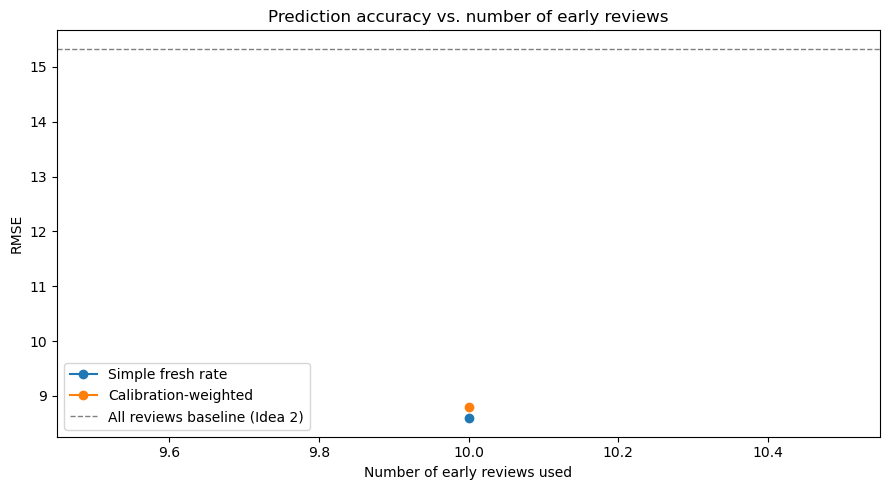


   N   Simple RMSE   Weighted RMSE   Weighted wins?
--------------------------------------------------
  10          8.59            8.79               no


In [ ]:
# Evaluate both approaches across a range of N early reviews
n_values = [1, 3, 5, 10, 15, 20, 30, 50]
results_simple, results_weighted = [], []

for n in n_values:
    data = early_review_predictions(n)
    y = data['tomatoMeter']

    X_s = data[['fresh_rate_pct']]
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y, test_size=0.2, random_state=42)
    rmse_s = np.sqrt(mean_squared_error(y_test_s, Ridge(alpha=1.0).fit(X_train_s, y_train_s).predict(X_test_s)))

    X_w = data[['weighted_fresh_score']]
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y, test_size=0.2, random_state=42)
    rmse_w = np.sqrt(mean_squared_error(y_test_w, Ridge(alpha=1.0).fit(X_train_w, y_train_w).predict(X_test_w)))

    results_simple.append(rmse_s)
    results_weighted.append(rmse_w)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, results_simple,  marker='o', label='Simple fresh rate')
ax.plot(n_values, results_weighted, marker='o', label='Calibration-weighted')
ax.axhline(15.33, color='gray', linestyle='--', linewidth=1, label='All reviews baseline (Idea 2)')
ax.set_xlabel('Number of early reviews used')
ax.set_ylabel('RMSE')
ax.set_title('Prediction accuracy vs. number of early reviews')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'N':>4}  {'Simple RMSE':>12}  {'Weighted RMSE':>14}  {'Weighted wins?':>15}")
print("-" * 50)
for n, rs, rw in zip(n_values, results_simple, results_weighted):
    print(f"{n:>4}  {rs:>12.2f}  {rw:>14.2f}  {'yes' if rw < rs else 'no':>15}")

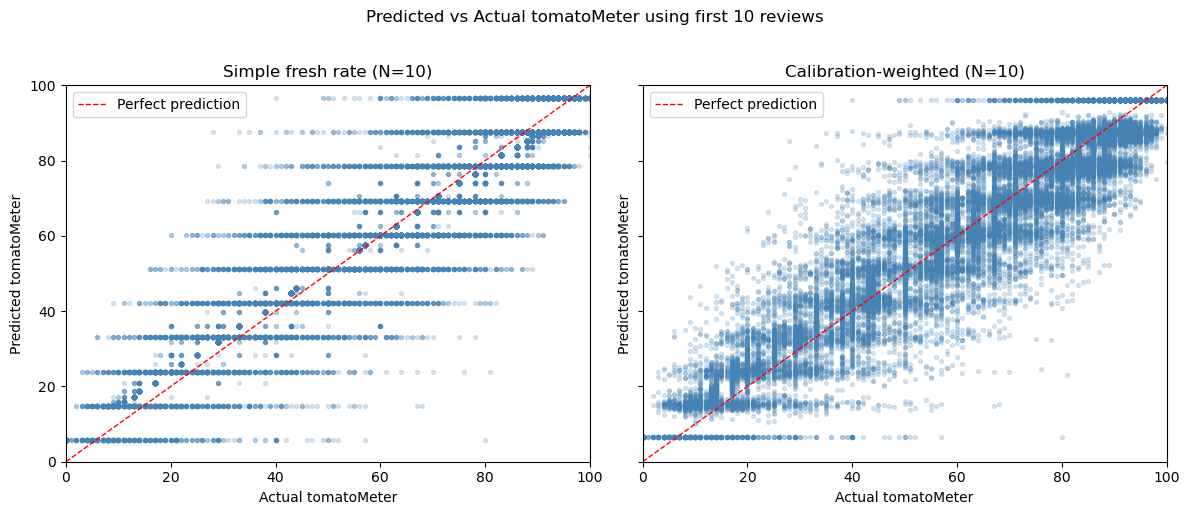

In [45]:
# Predicted vs actual tomatoMeter â€” visualize prediction quality at a chosen N
N = 10
data = early_review_predictions(N)
y_all = data['tomatoMeter']

m_s = Ridge(alpha=1.0).fit(data[['fresh_rate_pct']],      y_all)
m_w = Ridge(alpha=1.0).fit(data[['weighted_fresh_score']], y_all)

pred_simple   = m_s.predict(data[['fresh_rate_pct']])
pred_weighted = m_w.predict(data[['weighted_fresh_score']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, preds, label in zip(axes,
                             [pred_simple, pred_weighted],
                             [f'Simple fresh rate (N={N})', f'Calibration-weighted (N={N})']):
    ax.scatter(y_all, preds, alpha=0.2, s=8, color='steelblue')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual tomatoMeter')
    ax.set_ylabel('Predicted tomatoMeter')
    ax.set_title(label)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.legend()

plt.suptitle(f'Predicted vs Actual tomatoMeter using first {N} reviews', y=1.02)
plt.tight_layout()
plt.show()

##### **Findings:**
1. As the number of ratings you look at increases, the prediction accuracy increases exponentially. It looks like the first significant fall-off occurs when one uses less than 10 preliminary ratings. Thus, we will continue to investigate model options using the first 10 preliminary ratings, as that is a feasible number for future web-scraped data.

### **Idea 4: Pre-release Model: Director & Writer History + Genre Baseline**
These features are fully available before a movie releases â€” no reviews needed.
- **Director/writer historical avg**: leave-one-out average tomatoMeter across their prior films (excludes the current movie to prevent data leakage)
- **Genre baseline**: mean tomatoMeter per genre
- **MPAA rating**: encoded as a numeric feature

In [ ]:
movies_pr = movies.dropna(subset=['tomatoMeter']).copy()

def leave_one_out_avg(df, person_col):
    """
    For each movie, compute the leave-one-out average tomatoMeter for each
    person listed in person_col (comma-separated). Excludes the current movie
    to prevent leakage, then averages across co-directors/co-writers.
    """
    exploded = df[['id', 'tomatoMeter', person_col]].copy()
    exploded[person_col] = exploded[person_col].str.split(',')
    exploded = exploded.explode(person_col)
    exploded[person_col] = exploded[person_col].str.strip()

    # Total score and count per person across all their movies
    totals = exploded.groupby(person_col).agg(
        total=('tomatoMeter', 'sum'),
        count=('tomatoMeter', 'count')
    )
    exploded = exploded.join(totals, on=person_col)

    # Leave-one-out: subtract this movie's contribution
    exploded['loo_avg'] = np.where(
        exploded['count'] > 1,
        (exploded['total'] - exploded['tomatoMeter']) / (exploded['count'] - 1),
        np.nan  # only one film â€” no prior history
    )

    # For multi-director/writer movies, average their individual LOO scores
    return exploded.groupby('id')['loo_avg'].mean().rename(f'{person_col}_hist_avg')

director_hist = leave_one_out_avg(movies_pr, 'director')
writer_hist   = leave_one_out_avg(movies_pr, 'writer')

print("Director historical avg (sample):")
print(director_hist.dropna().head(10))
print(f"\nMovies with director history: {director_hist.notna().sum()} / {len(director_hist)}")

In [ ]:
# Genre baseline: mean tomatoMeter per genre (leave-one-out to prevent leakage)
# Genres are comma-separated â€” explode, compute LOO avg, re-aggregate per movie
genre_exploded = movies_pr[['id', 'tomatoMeter', 'genre']].copy()
genre_exploded['genre'] = genre_exploded['genre'].str.split(',')
genre_exploded = genre_exploded.explode('genre')
genre_exploded['genre'] = genre_exploded['genre'].str.strip()

genre_totals = genre_exploded.groupby('genre').agg(total=('tomatoMeter','sum'), count=('tomatoMeter','count'))
genre_exploded = genre_exploded.join(genre_totals, on='genre')
genre_exploded['genre_loo_avg'] = np.where(
    genre_exploded['count'] > 1,
    (genre_exploded['total'] - genre_exploded['tomatoMeter']) / (genre_exploded['count'] - 1),
    np.nan
)
genre_hist = genre_exploded.groupby('id')['genre_loo_avg'].mean().rename('genre_hist_avg')

# MPAA rating: encode as ordinal (stricter rating â†’ typically less critic-friendly)
rating_map = {'G': 1, 'PG': 2, 'PG-13': 3, 'R': 4, 'NC-17': 5, 'NR': 3}
movies_pr['rating_encoded'] = movies_pr['rating'].map(rating_map)

# Assemble pre-release feature matrix
prerelease = (movies_pr[['id', 'tomatoMeter', 'rating_encoded']]
              .join(director_hist, on='id')
              .join(writer_hist,   on='id')
              .join(genre_hist,    on='id')
              .dropna(subset=['director_hist_avg']))  # require at least director history

print(f"Movies in pre-release model: {len(prerelease)}")
print(prerelease[['director_hist_avg', 'writer_hist_avg', 'genre_hist_avg', 'rating_encoded', 'tomatoMeter']].describe())

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

features = ['director_hist_avg', 'writer_hist_avg', 'genre_hist_avg', 'rating_encoded']

# Fill missing writer/genre history with column mean (some first-time writers have no history)
X_pr = prerelease[features].fillna(prerelease[features].mean())
y_pr = prerelease['tomatoMeter']

X_train_pr, X_test_pr, y_train_pr, y_test_pr = train_test_split(X_pr, y_pr, test_size=0.2, random_state=42)

model_pr = Ridge(alpha=1.0)
model_pr.fit(X_train_pr, y_train_pr)

print(f"Pre-release model (director + writer + genre + rating):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_pr, model_pr.predict(X_test_pr))):.2f}")
print(f"  RÂ²:   {model_pr.score(X_test_pr, y_test_pr):.3f}")

print(f"\nFeature coefficients:")
for feat, coef in zip(features, model_pr.coef_):
    print(f"  {feat:<25} {coef:+.3f}")

##### **Findings:**
1. The model involving solely some of the movie metadata isn't great at predicting tomato score alone.

### **Idea 5: Publication-company Effects**
Do certain publications systematically score movies higher or lower than the final tomatoMeter?
- **Mean residual** (publication avg score âˆ’ tomatoMeter): positive = publication scores higher than consensus, negative = harsher than consensus
- **RMSE**: how consistently aligned the publication is with the final score (lower = more predictive)

In [23]:
# master_table_cleaned already has standardized_score and tomatoMeter from Idea 2
# Reuse residuals already computed there
pub_stats = (master_table_cleaned
    .groupby('publicatioName')
    .agg(
        review_count=('reviewId',         'count'),
        mean_bias   =('resid',            'mean'),   # positive = scores higher than tomatoMeter
        rmse        =('squared_resid',    lambda x: np.sqrt(x.mean())),
    )
    .reset_index()
    .sort_values('review_count', ascending=False))

print(f"Total publications: {len(pub_stats)}")
print("\nTop 15 publications by volume:")
print(pub_stats.head(15).to_string(index=False))

Total publications: 1957

Top 15 publications by volume:
               publicatioName  review_count  mean_bias      rmse
               Slant Magazine         10525  -9.576304 23.460298
              EmanuelLevy.Com         10054  -6.540979 21.209159
               New York Times          9358  -3.083137 21.181699
                     Guardian          9295 -10.142765 22.635677
Dennis Schwartz Movie Reviews          9189  -7.125911 20.156921
            Chicago Sun-Times          9030   6.971761 21.220112
           Common Sense Media          8655   0.444448 20.729321
                     Time Out          8464  -7.615595 21.199720
             Austin Chronicle          8343  -7.249634 20.914495
              eFilmCritic.com          8290   3.528854 21.173024
              Reeling Reviews          8089  -3.909507 18.701387
      San Francisco Chronicle          7893  -0.546750 23.540394
               Filmcritic.com          7823  -2.991499 21.849206
         Entertainment Weekly    

In [24]:
# Focus on publications with enough reviews to have a stable bias estimate
MIN_REVIEWS = 50
pub_reliable = pub_stats[pub_stats['review_count'] >= MIN_REVIEWS].copy()
print(f"Publications with {MIN_REVIEWS}+ reviews: {len(pub_reliable)}")

# Most positive and most negative bias
print("\nMost generous publications (score highest vs consensus):")
print(pub_reliable.nlargest(10, 'mean_bias')[['publicatioName', 'review_count', 'mean_bias', 'rmse']].to_string(index=False))

print("\nHarshest publications (score lowest vs consensus):")
print(pub_reliable.nsmallest(10, 'mean_bias')[['publicatioName', 'review_count', 'mean_bias', 'rmse']].to_string(index=False))

# Most and least consistent (by RMSE)
print("\nMost consistent publications (lowest RMSE):")
print(pub_reliable.nsmallest(10, 'rmse')[['publicatioName', 'review_count', 'mean_bias', 'rmse']].to_string(index=False))

Publications with 50+ reviews: 1073

Most generous publications (score highest vs consensus):
            publicatioName  review_count  mean_bias      rmse
         leonardmaltin.com           117  38.123932 46.100387
           CinemaSense.Com           149  21.208054 31.626172
               iF Magazine            79  18.848101 27.197124
         Film Quips Online           694  17.749280 27.429659
                 ESplatter           121  17.014876 27.571533
                 AALBC.com           244  15.338115 29.218317
      Indian Country Today            99  15.202020 27.398112
              Blunt Review           459  15.061438 28.243963
       3BlackChicks Review           344  14.950581 30.597490
Nolan's Pop Culture Review           451  14.906874 26.816387

Harshest publications (score lowest vs consensus):
    publicatioName  review_count  mean_bias      rmse
  San Diego Reader           996 -36.234940 43.392831
      Cine VÃ©rtigo           231 -33.218615 38.902989
   tonyma

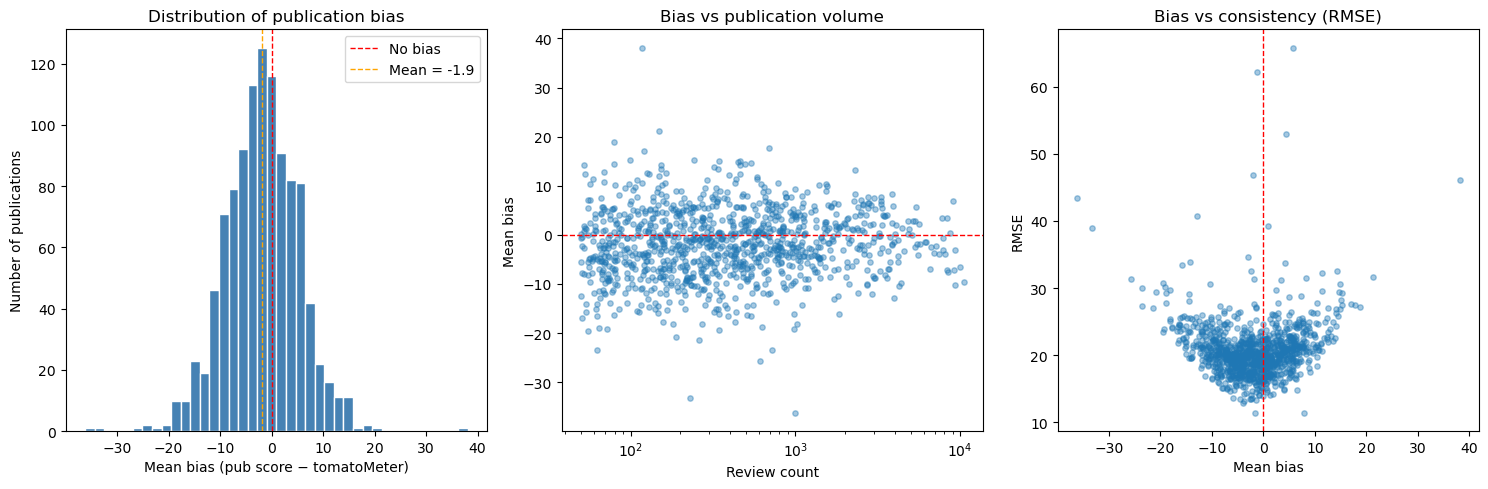

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribution of mean bias across publications
axes[0].hist(pub_reliable['mean_bias'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='No bias')
axes[0].axvline(pub_reliable['mean_bias'].mean(), color='orange', linestyle='--', linewidth=1, label=f"Mean = {pub_reliable['mean_bias'].mean():.1f}")
axes[0].set_xlabel('Mean bias (pub score âˆ’ tomatoMeter)')
axes[0].set_ylabel('Number of publications')
axes[0].set_title('Distribution of publication bias')
axes[0].legend()

# 2. Bias vs review count â€” does volume correlate with being more neutral?
axes[1].scatter(pub_reliable['review_count'], pub_reliable['mean_bias'], alpha=0.4, s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Review count')
axes[1].set_ylabel('Mean bias')
axes[1].set_title('Bias vs publication volume')
axes[1].set_xscale('log')

# 3. Bias vs RMSE â€” are biased publications also less consistent?
axes[2].scatter(pub_reliable['mean_bias'], pub_reliable['rmse'], alpha=0.4, s=15)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Mean bias')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Bias vs consistency (RMSE)')

plt.tight_layout()
plt.show()

##### **Findings:**
1. The publication bias of all the companies with more than 50 reviews, follows a **normal distribution**. aka: those who on average judge harsher vs lighter are symmetric 
2. As the number of publications for a company increases, their mean bias begins to converge towards 0 (as expected, central limit theorem)

### **Idea 6: Sentiment Analysis on Review Text**
Using VADER (Valence Aware Dictionary and Sentiment Reasoner) to score each review text from -1 (most negative) to +1 (most positive). Aggregated per movie and used as a predictor — first alone, then combined with the early fresh rate from Idea 3.

In [32]:
import subprocess
subprocess.run(["pip", "install", "nltk"], capture_output=True)
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
print("VADER ready")

VADER ready


In [33]:
# Merge reviewText into master_table_cleaned (already has tomatoMeter + reviewId)
reviews_text = reviews[["reviewId", "reviewText"]].dropna(subset=["reviewText"])
mt_sentiment = master_table_cleaned[["id", "reviewId", "criticName", "tomatoMeter"]].merge(
    reviews_text, on="reviewId", how="inner"
)
print(f"Reviews with text: {len(mt_sentiment)}")
print(f"Movies covered:    {mt_sentiment['id'].nunique()}")

Reviews with text: 897798
Movies covered:    32831


In [36]:
# Apply VADER to each review — compound score ranges from -1 to +1
sia = SentimentIntensityAnalyzer()

mt_sentiment["sentiment"] = mt_sentiment["reviewText"].apply(
    lambda text: sia.polarity_scores(str(text))["compound"]
)

print("Sentiment score distribution:")
print(mt_sentiment["sentiment"].describe().round(3))

Sentiment score distribution:
count    897798.000
mean          0.207
std           0.493
min          -0.992
25%          -0.103
50%           0.273
75%           0.637
max           0.991
Name: sentiment, dtype: float64


In [37]:
# Aggregate per movie: mean sentiment score
movie_sentiment = (
    mt_sentiment
    .groupby("id")
    .agg(mean_sentiment=("sentiment", "mean"),
         review_count   =("reviewId",  "count"))
    .reset_index())

movie_tomato_s = mt_sentiment[["id", "tomatoMeter"]].drop_duplicates()
sentiment_data = movie_sentiment.merge(movie_tomato_s, on="id").dropna()
print(f"Movies in sentiment model: {len(sentiment_data)}")

corr = sentiment_data["mean_sentiment"].corr(sentiment_data["tomatoMeter"])
print(f"Correlation (sentiment vs tomatoMeter): {corr:.3f}")

Movies in sentiment model: 32831
Correlation (sentiment vs tomatoMeter): 0.306


In [38]:

X_sent = sentiment_data[["mean_sentiment"]]
y_sent = sentiment_data["tomatoMeter"]
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(X_sent, y_sent, test_size=0.2, random_state=42)

model_sent = Ridge(alpha=1.0)
model_sent.fit(X_train_sent, y_train_sent)

print("Sentiment-only model:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_sent, model_sent.predict(X_test_sent))):.2f}")
print(f"  R²:   {model_sent.score(X_test_sent, y_test_sent):.3f}")

Sentiment-only model:
  RMSE: 26.90
  R²:   0.097


In [47]:
# Combined model: early fresh rate (N=10) + sentiment from same first N reviews
# Both features use only the first N reviews — no future data leakage
N = 10

# Get the first N reviews per movie (sorted by date, same as early_review_predictions)
early_reviews = mt_fresh_sorted.groupby('id', group_keys=False).head(N)

# Merge in review text and compute sentiment on first N reviews only
early_with_text = early_reviews.merge(
    reviews[['reviewId', 'reviewText']], on='reviewId', how='inner'
).dropna(subset=['reviewText'])

early_with_text['sentiment'] = early_with_text['reviewText'].apply(
    lambda text: sia.polarity_scores(str(text))['compound']
)

# Aggregate both features per movie from first N reviews
early_features = (early_with_text
    .groupby('id')
    .agg(fresh_rate_pct =('is_fresh',  lambda x: x.mean() * 100),
         mean_sentiment  =('sentiment', 'mean'))
    .reset_index())

movie_tomato_s2 = mt_fresh_sorted[['id', 'tomatoMeter']].drop_duplicates()
combined = early_features.merge(movie_tomato_s2, on='id').dropna()
print(f"Movies in combined model: {len(combined)}")

features_combined = ['fresh_rate_pct', 'mean_sentiment']
X_c = combined[features_combined]
y_c = combined['tomatoMeter']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

model_combined = Ridge(alpha=1.0)
model_combined.fit(X_train_c, y_train_c)

print(f"Combined model (fresh rate N={N} + sentiment from first {N} reviews):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_c, model_combined.predict(X_test_c))):.2f}")
print(f"  R²:   {model_combined.score(X_test_c, y_test_c):.3f}")
print(f"Feature coefficients:")
for feat, coef in zip(features_combined, model_combined.coef_):
    print(f"  {feat:<20} {coef:+.4f}")

Movies in combined model: 33305
Combined model (fresh rate N=10 + sentiment from first 10 reviews):
  RMSE: 10.84
  R²:   0.851
Feature coefficients:
  fresh_rate_pct       +0.8611
  mean_sentiment       +0.1850


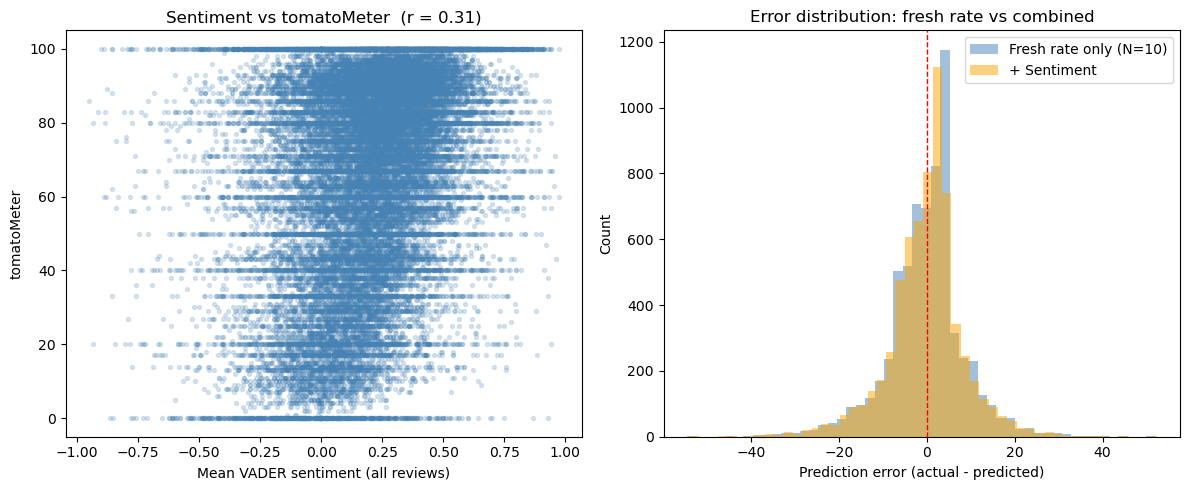

In [42]:
# Plot 1: sentiment vs tomatoMeter scatter
# Plot 2: error distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(sentiment_data["mean_sentiment"], sentiment_data["tomatoMeter"],
                alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("Mean VADER sentiment (all reviews)")
axes[0].set_ylabel("tomatoMeter")
axes[0].set_title(f"Sentiment vs tomatoMeter  (r = {corr:.2f})")

err_fresh    = y_test_c - Ridge(alpha=1.0).fit(X_train_c[["fresh_rate_pct"]], y_train_c).predict(X_test_c[["fresh_rate_pct"]])
err_combined = y_test_c - model_combined.predict(X_test_c)

axes[1].hist(err_fresh,    bins=50, alpha=0.5, label=f"Fresh rate only (N={N})", color="steelblue")
axes[1].hist(err_combined, bins=50, alpha=0.5, label="+ Sentiment",             color="orange")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Prediction error (actual - predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Error distribution: fresh rate vs combined")
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
# R² for simple fresh rate model using first 10 reviews (to compare against combined model)
data = early_review_predictions(10)
y = data['tomatoMeter']
X = data[['fresh_rate_pct']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
m = Ridge(alpha=1.0).fit(X_train, y_train)
print(f"Simple fresh rate (N=10)  R²: {m.score(X_test, y_test):.3f}")
print(f"Simple fresh rate (N=10)  RMSE: {np.sqrt(mean_squared_error(y_test, m.predict(X_test))):.2f}")

Simple fresh rate (N=10)  R²: 0.905
Simple fresh rate (N=10)  RMSE: 8.59


##### **Findings & Notes:**
(note): Used a VADER Model (lightweight), try BERT Model (deep learning, transformer) next. 

1. Using sentiment alone has very poor predicting power for tomato score, with an R^2 of 0.1 and correlation of 0.3. 

2. Using the simple fresh rate and sentiment scores of the first 10 ratings, our model has an R^2 of 0.851, which is slightly worse than using simple fresh rate % alone. This means that the sentiment scores via VADER are merely noise.

### **Idea 6 (cont): Using Twitter-roBERTa-base model for sentiment analysis instead of VADER** 

In [ ]:
import subprocess
subprocess.run(["pip", "install", "transformers", "torch"], capture_output=True)
from transformers import pipeline

# Load model — LABEL_0=negative, LABEL_1=neutral, LABEL_2=positive
# top_k=None returns scores for all 3 classes so we can compute a continuous score
roberta = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    max_length=128,
    truncation=True,
    top_k=None
)
print("Model loaded")

In [ ]:
# Limit to first N reviews per movie (same chronological slice as Idea 3)
# Running RoBERTa on all 1.4M reviews would be very slow on CPU
N = 10
early_text = (mt_fresh_sorted
    .groupby("id", group_keys=False)
    .head(N)
    .merge(reviews[["reviewId", "reviewText"]], on="reviewId", how="inner")
    .dropna(subset=["reviewText"]))

print(f"Reviews to score: {len(early_text)}")
print(f"Sample text: {early_text["reviewText"].iloc[0][:120]}")

In [54]:
# Score in batches — continuous score = P(positive) - P(negative)
def roberta_score(texts, batch_size=32):
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        results = roberta(batch)
        for r in results:
            label_scores: dict[str, float] = {d["label"]: float(d["score"]) for d in r}  # type: ignore[index]
            score = label_scores.get("LABEL_2", 0.0) - label_scores.get("LABEL_0", 0.0)
            scores.append(score)
    return scores

# Only score a random sample of 1000 movies
sample_ids = early_text["id"].drop_duplicates().sample(1000, random_state=42)
early_text_sample = early_text[early_text["id"].isin(sample_ids)].copy()
texts = early_text_sample["reviewText"].astype(str).tolist()

early_text_sample["roberta_sentiment"] = roberta_score(texts)

print("Scoring complete")
print(early_text_sample["roberta_sentiment"].describe().round(3))

Scoring complete
count    8079.000
mean        0.135
std         0.626
min        -0.981
25%        -0.433
50%         0.184
75%         0.742
max         0.990
Name: roberta_sentiment, dtype: float64


In [55]:
# Aggregate per movie: fresh rate + RoBERTa sentiment from first N reviews
roberta_features = (early_text_sample
    .groupby("id")
    .agg(fresh_rate_pct   =("is_fresh",          lambda x: x.mean() * 100),
         roberta_sentiment =("roberta_sentiment", "mean"))
    .reset_index())

movie_tomato_rb = mt_fresh_sorted[["id", "tomatoMeter"]].drop_duplicates()
roberta_data = roberta_features.merge(movie_tomato_rb, on="id").dropna()
print(f"Movies in RoBERTa model: {len(roberta_data)}")

corr_rb = roberta_data["roberta_sentiment"].corr(roberta_data["tomatoMeter"])
print(f"Correlation (RoBERTa sentiment vs tomatoMeter): {corr_rb:.3f}")
print(f"cf. VADER correlation:                          {sentiment_data['mean_sentiment'].corr(sentiment_data['tomatoMeter']):.3f}")

Movies in RoBERTa model: 1000
Correlation (RoBERTa sentiment vs tomatoMeter): 0.687
cf. VADER correlation:                          0.306


In [56]:

results_rb = {}
y_rb = roberta_data["tomatoMeter"]

for name, feats in [
    ("Fresh rate only",              ["fresh_rate_pct"]),
    ("RoBERTa sentiment only",       ["roberta_sentiment"]),
    ("Fresh rate + RoBERTa",         ["fresh_rate_pct", "roberta_sentiment"]),
]:
    X = roberta_data[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_rb, test_size=0.2, random_state=42)
    m = Ridge(alpha=1.0).fit(X_tr, y_tr)
    results_rb[name] = {"rmse": np.sqrt(mean_squared_error(y_te, m.predict(X_te))),
                        "r2":   m.score(X_te, y_te)}

print(f"{"Model":<35} {"RMSE":>6}  {"R²":>6}")
print("-" * 52)
for name, metrics in results_rb.items():
    print(f"{name:<35} {metrics["rmse"]:>6.2f}  {metrics["r2"]:>6.3f}")

Model                                 RMSE      R²
----------------------------------------------------
Fresh rate only                       9.82   0.880
RoBERTa sentiment only               20.24   0.491
Fresh rate + RoBERTa                  9.87   0.879


##### **Findings:** 
(Note): Used a sample of 1000 movies to calculate the ROBERTa sentiment scores.

1. The ROBERTa sentiment scores has a 0.687 correlation with tomato score, medium strength. 
2. The ROBERTa sentiment + fresh rate model performs about the same as the fresh rate only model. 
3. ROBERTa sentiment scores are much more useful than the VADER scores.